## Pre-Processing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

Mounted at /content/drive


In [ ]:
#Importing dataset and turning it into a dataframe

df = pd.read_csv("/content/drive/MyDrive/DATA/global_ai_jobs.csv")

df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [ ]:
#checking for NA values

df.isna().sum()

,0
id,0
country,0
job_role,0
ai_specialization,0
experience_level,0
experience_years,0
salary_usd,0
bonus_usd,0
education_required,0
industry,0


In [ ]:
#find duplicates

df[df.duplicated(keep=False)].sum()


,0
id,0
country,0
job_role,0
ai_specialization,0
experience_level,0
experience_years,0
salary_usd,0
bonus_usd,0
education_required,0
industry,0


In [ ]:
#find data types

df.dtypes

,0
id,int64
country,object
job_role,object
ai_specialization,object
experience_level,object
experience_years,int64
salary_usd,int64
bonus_usd,int64
education_required,object
industry,object


In [ ]:
#mapping to strings

df = df.astype({'country': str, 'job_role': str, 'ai_specialization': str, 'experience_level': str, 'education_required': str, 'industry': str, 'company_size': str, 'work_mode': str, })

In [ ]:
#looking at the columns

df.columns

Index(['id', 'country', 'job_role', 'ai_specialization', 'experience_level',
       'experience_years', 'salary_usd', 'bonus_usd', 'education_required',
       'industry', 'company_size', 'interview_rounds', 'year', 'work_mode',
       'weekly_hours', 'company_rating', 'job_openings',
       'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score',
       'company_funding_billion', 'economic_index', 'ai_maturity_years',
       'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days',
       'skill_demand_score', 'automation_risk', 'job_security_score',
       'career_growth_score', 'work_life_balance_score', 'promotion_speed',
       'salary_percentile', 'cost_of_living_index', 'employee_satisfaction'],
      dtype='object')

## EDA

In [ ]:
print(f"Dataset contains {df.shape[0]} entries and {df.shape[1]} features.\n")

print("\n--- Information ---\n") ##why is this not showing up?
df.info()

print("\n--- Summary ---\n")
df.describe()

print("\n--- Checking for Over-represented Features ---\n")
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}':\n{df[col].value_counts().head(10)}\n")

print("\n--- Correlation Matrix ---\n")
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
display(correlation_matrix)

Dataset contains 90000 entries and 35 features.


--- Information ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
id,1.000000,0.001841,0.007894,0.003261,-0.003397,0.003830,-0.002532,-0.004251,0.001834,0.000831,...,0.000019,-0.003792,0.004279,0.001153,-0.003507,0.006872,-0.000345,-0.000167,-0.003333,0.004867
experience_years,0.001841,1.000000,0.723879,0.545966,-0.005699,0.000253,-0.004406,0.004693,0.000691,0.001893,...,-0.004695,0.000309,0.003161,0.599466,0.007329,0.004165,0.363093,-0.003814,-0.000504,0.517066
salary_usd,0.007894,0.723879,1.000000,0.752046,-0.006230,-0.001309,-0.004970,-0.000347,0.003853,-0.000759,...,-0.006457,0.001087,0.002201,0.434177,0.003107,0.003890,0.261381,-0.003327,0.001462,0.629030
bonus_usd,0.003261,0.545966,0.752046,1.000000,-0.000935,0.002574,-0.002344,0.001736,0.004792,-0.000395,...,-0.006002,0.001459,0.004375,0.323791,0.003217,-0.000007,0.200770,-0.002921,0.002414,0.471220
interview_rounds,-0.003397,-0.005699,-0.006230,-0.000935,1.000000,-0.001724,0.002794,-0.000020,0.000547,0.002658,...,-0.003531,0.004476,-0.001391,-0.008056,0.002056,-0.002010,-0.000859,-0.002871,-0.000128,-0.005249
year,0.003830,0.000253,-0.001309,0.002574,-0.001724,1.000000,-0.000237,0.002733,0.003498,-0.001752,...,0.000196,0.004989,0.004411,0.001453,-0.003908,0.000372,0.000601,-0.000705,-0.002321,-0.002956
weekly_hours,-0.002532,-0.004406,-0.004970,-0.002344,0.002794,-0.000237,1.000000,0.002996,0.000721,0.004533,...,0.010298,-0.003575,0.003114,-0.001098,0.007250,-0.828129,-0.004508,0.001682,0.005979,-0.340942
company_rating,-0.004251,0.004693,-0.000347,0.001736,-0.000020,0.002733,0.002996,1.000000,0.001081,0.004933,...,-0.001946,-0.003076,0.002467,0.000561,-0.004091,-0.000381,-0.006642,0.002993,0.002303,0.001647
job_openings,0.001834,0.000691,0.003853,0.004792,0.000547,0.003498,0.000721,0.001081,1.000000,-0.003196,...,-0.000350,-0.001368,-0.002554,0.002749,-0.003083,-0.000346,-0.001725,-0.006480,0.000364,0.000449
hiring_difficulty_score,0.000831,0.001893,-0.000759,-0.000395,0.002658,-0.001752,0.004533,0.004933,-0.003196,1.000000,...,-0.007393,0.000155,0.002565,0.000677,-0.002118,-0.004073,0.005938,-0.000692,0.004137,-0.004272


## Conclusion 1: Outliers?

Outliers are in red. We can see that salary, bonus, and hiring difficulty score all had outliers.


--- Outliers ---



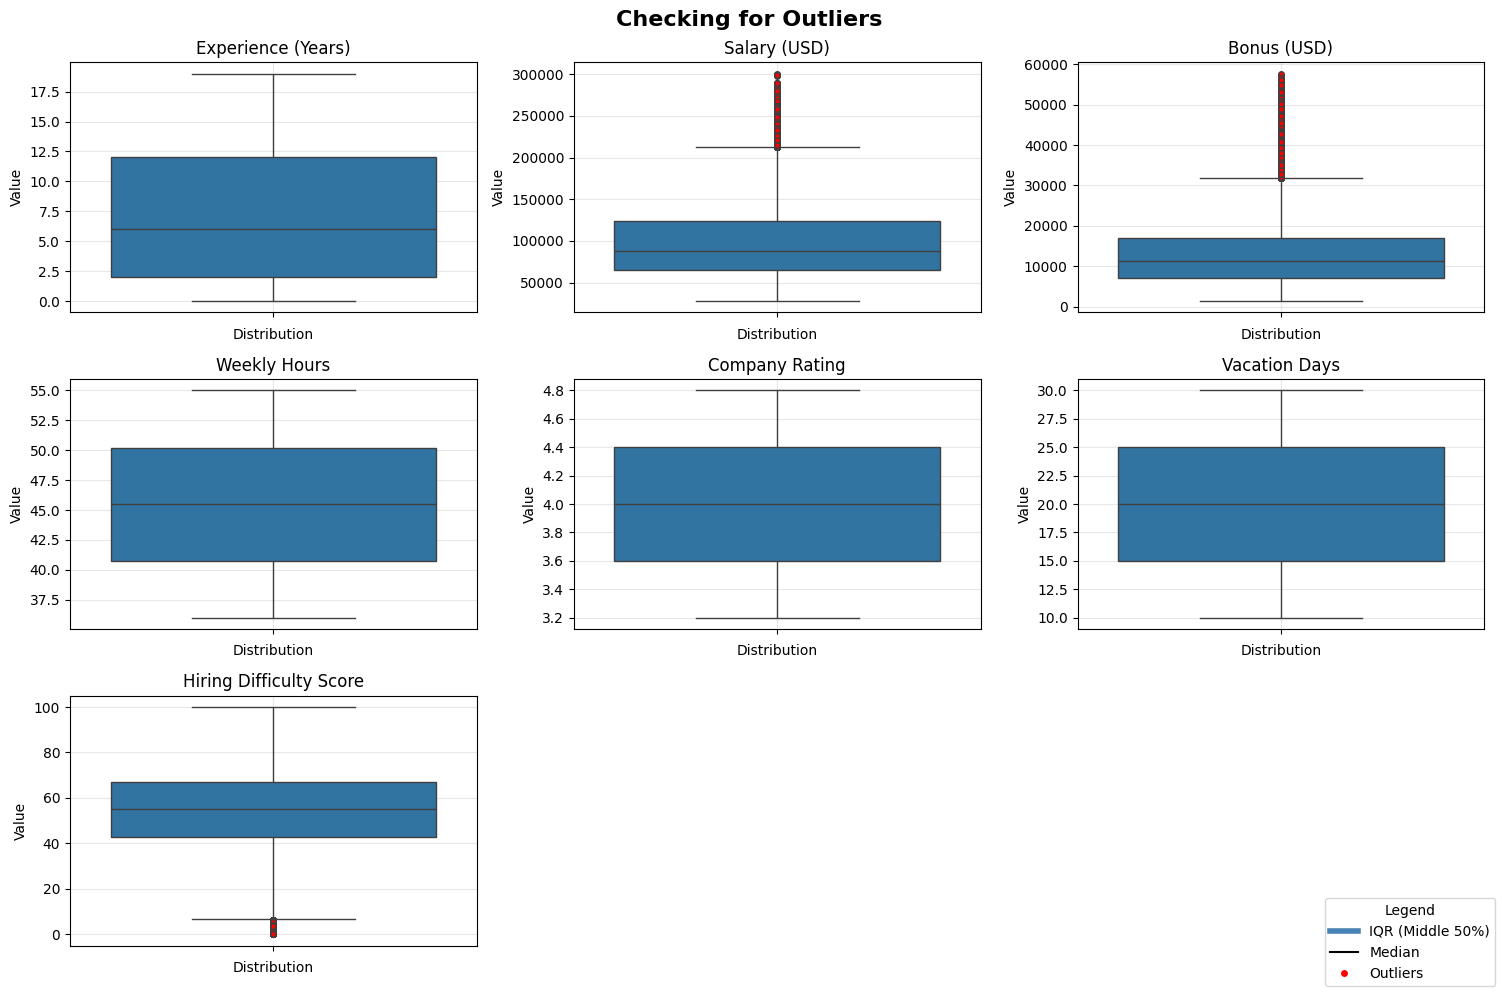

In [ ]:
print("\n--- Outliers ---\n")
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

selected_numerical_cols = ['experience_years', 'salary_usd', 'bonus_usd',
                           'weekly_hours', 'company_rating', 'vacation_days',
                           'hiring_difficulty_score']

titles = ['Experience (Years)', 'Salary (USD)', 'Bonus (USD)',
          'Weekly Hours', 'Company Rating', 'Vacation Days',
          'Hiring Difficulty Score']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Checking for Outliers', fontsize=16, fontweight='bold')
#boxes
for i, (col, title) in enumerate(zip(selected_numerical_cols, titles)):
    ax = axes[i // 3][i % 3]
    sns.boxplot(y=df[col], ax=ax,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Value')
    ax.set_xlabel('Distribution')
    ax.grid(True, alpha=0.3)

#legend
legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=4, label='IQR (Middle 50%)'),
    Line2D([0], [0], color='black', linewidth=1.5, label='Median'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Outliers')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Legend')

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)
plt.tight_layout()
plt.show()

## Conclusion 2: Hypothesis Testing
The result shows a statistically significant difference amongst (at least) one pair in the dataset. By looking at the graph, it looks like Data Analyst.

Hypothesis Testing: Is there a significant difference in average salary across different job roles?

Null Hypothesis (H0): There is no significant difference in the mean salary_usd across different job_role categories.
Alternative Hypothesis (Ha): There is a significant difference in the mean salary_usd for at least one job_role group.

ANOVA F-statistic: 864.24
ANOVA P-value: 0.000e+00

Conclusion (at alpha = 0.05):
Since the p-value is less than alpha, we reject the Null Hypothesis.
This suggests that there is a statistically significant difference in the average salary across at least two job roles.

Note: The ANOVA test assumes normality of the samples and homogeneity of variances. Further tests (e.g., Levene's test for homogeneity of variance, Shapiro-Wilk for normality) could be performed to validate these assumptions. If assumptions are violated, non-parametric tests like Kruskal-Wallis H-test might be more appropriate, or transformations of the data may be considered.


/tmp/ipykernel_3611/4281342597.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='job_role', y='salary_usd', palette='muted', inner='quartile')


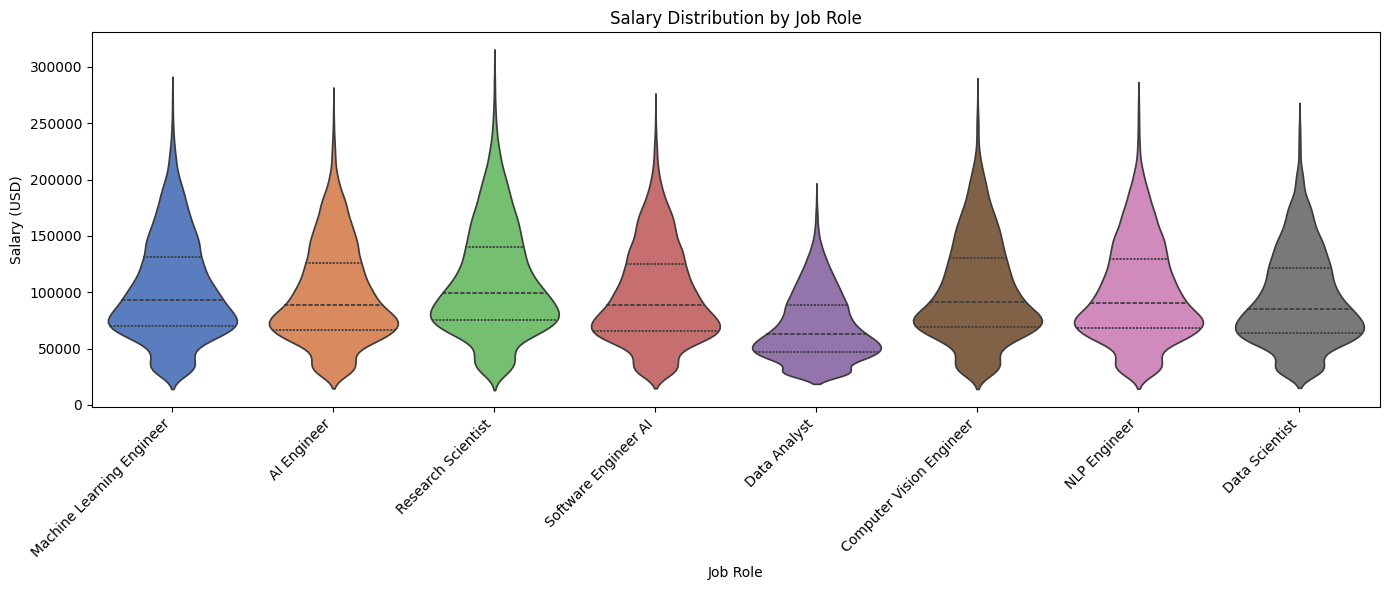

In [ ]:
from scipy import stats

# Define the null and alternative hypotheses
print("Hypothesis Testing: Is there a significant difference in average salary across different job roles?\n")
print("Null Hypothesis (H0): There is no significant difference in the mean salary_usd across different job_role categories.")
print("Alternative Hypothesis (Ha): There is a significant difference in the mean salary_usd for at least one job_role group.\n")

# Prepare data for ANOVA
job_roles = df['job_role'].unique()
salaries_by_job_role = [df['salary_usd'][df['job_role'] == role] for role in job_roles]

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*salaries_by_job_role)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3e}") # Display p-value in scientific notation for very small values

# Draw a conclusion based on the p-value
alpha = 0.05
print(f"\nConclusion (at alpha = {alpha}):")
if p_value < alpha:
    print("Since the p-value is less than alpha, we reject the Null Hypothesis.")
    print("This suggests that there is a statistically significant difference in the average salary across at least two job roles.")
else:
    print("Since the p-value is greater than or equal to alpha, we fail to reject the Null Hypothesis.")
    print("This suggests that there is no statistically significant difference in the average salary across different job roles.")

print("\nNote: The ANOVA test assumes normality of the samples and homogeneity of variances. Further tests (e.g., Levene's test for homogeneity of variance, Shapiro-Wilk for normality) could be performed to validate these assumptions. If assumptions are violated, non-parametric tests like Kruskal-Wallis H-test might be more appropriate, or transformations of the data may be considered.")

plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='job_role', y='salary_usd', palette='muted', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

## Conlusion 3: Linear Regression

Hypothesis Testing: Is there a linear relationship between experience_years and salary_usd?

Null Hypothesis (H0): There is no linear relationship between experience_years and salary_usd (beta_1 = 0).
Alternative Hypothesis (Ha): There is a linear relationship between experience_years and salary_usd (beta_1 != 0).

                            OLS Regression Results                            
Dep. Variable:             salary_usd   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                 9.907e+04
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:19:36   Log-Likelihood:            -1.0564e+06
No. Observations:               90000   AIC:                         2.113e+06
Df Residuals:                   89998   BIC:                         2.113e+06
Df Model:                           1              

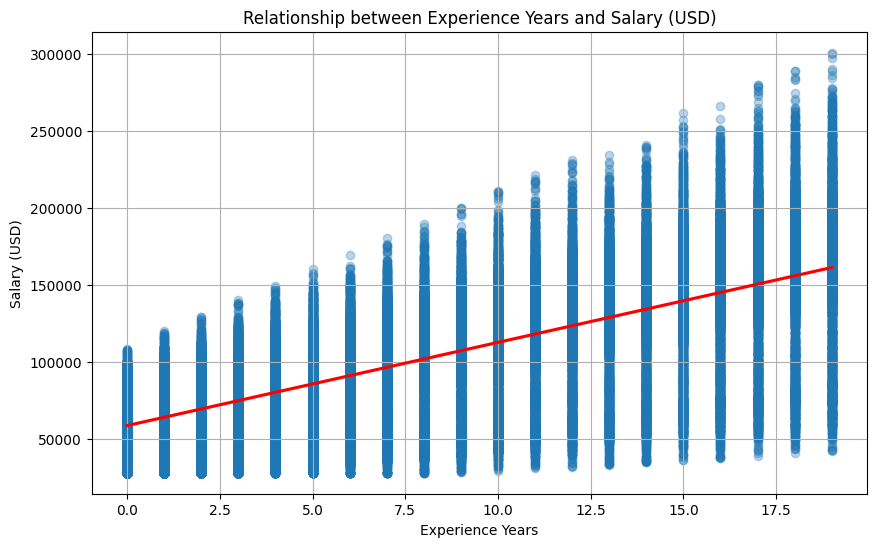

In [ ]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

print("Hypothesis Testing: Is there a linear relationship between experience_years and salary_usd?\n")
print("Null Hypothesis (H0): There is no linear relationship between experience_years and salary_usd (beta_1 = 0).")
print("Alternative Hypothesis (Ha): There is a linear relationship between experience_years and salary_usd (beta_1 != 0).\n")

# Define dependent and independent variables
X = df['experience_years']
y = df['salary_usd']

# Add a constant to the independent variable for intercept calculation
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())

# Draw a conclusion based on the p-value of experience_years
alpha = 0.05
p_value_experience_years = results.pvalues['experience_years']

print(f"\nConclusion (at alpha = {alpha}):")
if p_value_experience_years < alpha:
    print("Since the p-value for 'experience_years' is less than alpha, we reject the Null Hypothesis.")
    print("This suggests that there is a statistically significant linear relationship between experience_years and salary_usd.")
else:
    print("Since the p-value for 'experience_years' is greater than or equal to alpha, we fail to reject the Null Hypothesis.")
    print("This suggests that there is no statistically significant linear relationship between experience_years and salary_usd.")

print("\n--- Visualization: Scatter plot with Regression Line ---\n")
plt.figure(figsize=(10, 6))
sns.regplot(x='experience_years', y='salary_usd', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Experience Years and Salary (USD)')
plt.xlabel('Experience Years')
plt.ylabel('Salary (USD)')
plt.grid(True)
plt.show()